In [6]:
#First we Importing libraries 

import pandas as pd
import seaborn as sns 
import numpy as np 
import matplotlib as plt

# Data Loading from CSV file

df = pd.read_csv(r"D:\A Skills Upgradation\Internship Project Work 06 June\online_retail_dataset Detailed .csv")

print("Rows,Col" ,df.shape)

Rows,Col (49782, 17)


In [ ]:
Performing EDA Before Cleaning, We can analyse the change better

In [7]:
#showing top 5 rows of data 

df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Discount,PaymentMethod,ShippingCost,Category,SalesChannel,ReturnStatus,ShipmentProvider,WarehouseLocation,OrderPriority
0,221958,SKU_1964,White Mug,38,1/1/2020 0:00,1.71,37039.0,Australia,0.470000,Bank Transfer,10.79,Apparel,In-store,Not Returned,UPS,London,Medium
1,771155,SKU_1241,White Mug,18,1/1/2020 1:00,41.25,19144.0,Spain,0.190000,paypall,9.51,Electronics,Online,Not Returned,UPS,Rome,Medium
2,231932,SKU_1501,Headphones,49,1/1/2020 2:00,29.11,50472.0,Germany,0.350000,Bank Transfer,23.03,Electronics,Online,Returned,UPS,Berlin,High
3,465838,SKU_1760,Desk Lamp,14,1/1/2020 3:00,76.68,96586.0,Netherlands,0.140000,paypall,11.08,Accessories,Online,Not Returned,Royal Mail,Rome,Low
4,359178,SKU_1386,USB Cable,-30,1/1/2020 4:00,-68.11,NaN,United Kingdom,1.501433,Bank Transfer,NaN,Electronics,In-store,Not Returned,FedEx,NaN,Medium


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49782 entries, 0 to 49781
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   InvoiceNo          49782 non-null  int64  
 1   StockCode          49782 non-null  object 
 2   Description        49782 non-null  object 
 3   Quantity           49782 non-null  int64  
 4   InvoiceDate        49782 non-null  object 
 5   UnitPrice          49782 non-null  float64
 6   CustomerID         35389 non-null  float64
 7   Country            49782 non-null  object 
 8   Discount           49782 non-null  float64
 9   PaymentMethod      49782 non-null  object 
 10  ShippingCost       47293 non-null  float64
 11  Category           49782 non-null  object 
 12  SalesChannel       49782 non-null  object 
 13  ReturnStatus       49782 non-null  object 
 14  ShipmentProvider   49782 non-null  object 
 15  WarehouseLocation  46297 non-null  object 
 16  OrderPriority      497

In [10]:
# Counting Missing Values

df.isnull().sum()

InvoiceNo                0
StockCode                0
Description              0
Quantity                 0
InvoiceDate              0
UnitPrice                0
CustomerID           14393
Country                  0
Discount                 0
PaymentMethod            0
ShippingCost          2489
Category                 0
SalesChannel             0
ReturnStatus             0
ShipmentProvider         0
WarehouseLocation     3485
OrderPriority            0
dtype: int64

In [11]:
#summary of dataset 

df.describe()

,InvoiceNo,Quantity,UnitPrice,CustomerID,Discount,ShippingCost
count,49782.000000,49782.000000,49782.000000,35389.000000,49782.000000,47293.000000
mean,550681.239946,22.372343,47.537862,54982.564413,0.275748,17.494529
std,260703.009944,17.917774,33.479510,25939.914880,0.230077,7.220557
min,100005.000000,-50.000000,-99.980000,10001.000000,0.000000,5.000000
25%,324543.000000,11.000000,23.592500,32638.000000,0.130000,11.220000
50%,552244.000000,23.000000,48.920000,55054.000000,0.260000,17.500000
75%,776364.000000,37.000000,74.610000,77290.000000,0.380000,23.720000
max,999997.000000,49.000000,100.000000,99998.000000,1.999764,30.000000


In [12]:
import seaborn as sns
import matplotlib as plt

<Axes: xlabel='Quantity', ylabel='Count'>

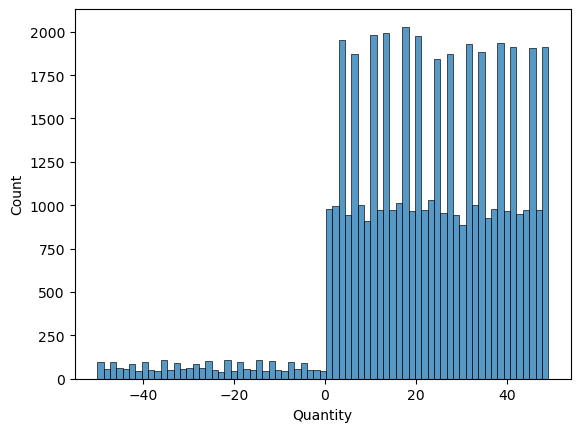

In [13]:
sns.histplot(df['Quantity']) 

In [82]:
#Data Cleaning Steps 
#Fix missing values

df['ShippingCost'] = df['ShippingCost'].fillna(df.groupby('Country')['ShippingCost'].transform('median'))

df['WarehouseLocation'] = df['WarehouseLocation'].fillna('Unknown')

In [87]:
# Dropping invalid rows for Customer ID only 
df = df.dropna(subset=['CustomerID'])

# Filtering out the negative value 
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

#duplicate removed 
df = df.drop_duplicates()

In [95]:
# Again we are checking, and there is no null values in dataset 

df.isnull().sum()

InvoiceNo            0
StockCode            0
Description          0
Quantity             0
InvoiceDate          0
UnitPrice            0
CustomerID           0
Country              0
Discount             0
PaymentMethod        0
ShippingCost         0
Category             0
SalesChannel         0
ReturnStatus         0
ShipmentProvider     0
WarehouseLocation    0
OrderPriority        0
dtype: int64

In [86]:
#Converting date-time into python date-time

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(df["InvoiceDate"].iloc[0])

2020-01-01 00:00:00


In [91]:
df.shape

(44804, 17)

In [96]:
# Fix types and values

df['PaymentMethod'] = df['PaymentMethod'].str.replace('paypall', 'PayPal', case=False)

df['Discount'] = df['Discount'].clip(upper=1.0)

In [98]:
#Adding new Columns for better analysis 

df['TotalRevenue'] = df['Quantity'] * df['UnitPrice'] * (1 - df['Discount'])

df['SaleDate'] = df['InvoiceDate'].dt.date
df['Month'] = df['InvoiceDate'].dt.month
df['Year'] = df['InvoiceDate'].dt.year


In [99]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Discount,PaymentMethod,...,Category,SalesChannel,ReturnStatus,ShipmentProvider,WarehouseLocation,OrderPriority,TotalRevenue,SaleDate,Month,Year
0,221958,SKU_1964,White Mug,38,2020-01-01 00:00:00,1.71,37039.0,Australia,0.47,Bank Transfer,...,Apparel,In-store,Not Returned,UPS,London,Medium,34.4394,2020-01-01,1,2020
1,771155,SKU_1241,White Mug,18,2020-01-01 01:00:00,41.25,19144.0,Spain,0.19,PayPal,...,Electronics,Online,Not Returned,UPS,Rome,Medium,601.4250,2020-01-01,1,2020
2,231932,SKU_1501,Headphones,49,2020-01-01 02:00:00,29.11,50472.0,Germany,0.35,Bank Transfer,...,Electronics,Online,Returned,UPS,Berlin,High,927.1535,2020-01-01,1,2020
3,465838,SKU_1760,Desk Lamp,14,2020-01-01 03:00:00,76.68,96586.0,Netherlands,0.14,PayPal,...,Accessories,Online,Not Returned,Royal Mail,Rome,Low,923.2272,2020-01-01,1,2020
5,744167,SKU_1006,Office Chair,47,2020-01-01 05:00:00,70.16,53887.0,Sweden,0.48,Credit Card,...,Electronics,Online,Not Returned,DHL,London,Medium,1714.7104,2020-01-01,1,2020


<Axes: xlabel='Quantity', ylabel='Count'>

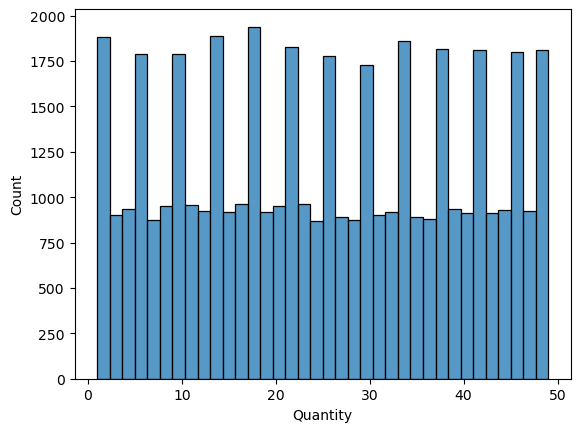

In [101]:
sns.histplot(df['Quantity'])

In [103]:
# Export
df.to_csv("cleaned.csv", index=True)
print(f"Final shape: {df.shape}")

Final shape: (44804, 21)
